In [1]:
%matplotlib widget
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy import interpolate
import sys
from tqdm import tqdm

sys.path.append('/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability')
import proba_modules as pm
reload(pm)

<module 'proba_modules' from '/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/proba_modules.py'>

In [2]:
file_atmos = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/data/profile_VCD_for_scaling_pd.csv'
profile = pd.read_csv(file_atmos)
f_rho = interpolate.interp1d(profile.altitude/1e3, profile.rho, kind='quadratic')
f_t = interpolate.interp1d(profile.altitude/1e3, profile.t, kind='quadratic')
f_gamma = interpolate.interp1d(profile.altitude/1e3, profile.gamma, kind='quadratic')
f_c = interpolate.interp1d(profile.altitude/1e3, profile.c, kind='quadratic')

In [3]:
reload(pm)

dir_GF = '/projects/restricted/infrasound/data/infrasound/2023_Venus_inversion/'
freq = [0.01, 0.1, 1.]
#alt_balloon = 45.

files = ['GF_Dirac_1Hz_all_wfreq_Cold100_atten_v.csv',
        'GF_Dirac_1Hz_all_wfreq_Hot25_atten_v.csv',
        'GF_Dirac_1Hz_all_wfreq_Hot10_atten_v.csv',
        'GF_Dirac_1Hz_all_wfreq_Hot40_atten_v.csv']
depths = [[0, 40],
         [0, 17],
         [0, 11],
         [0, 21],]
depths = [[0, 20],
         [0, 5],
         [0, 5],
         [0, 11],]

#files = ['GF_Dirac_1Hz_all_wfreq_Cold100.csv',]
#depths = [[0, 40],]

dists = np.arange(0, 18000., 5.)
m0_default = 6. 

TL_all = pd.DataFrame()
for depths_loc, file in tqdm(zip(depths, files), total=len(files)):
    file_curve = f'{dir_GF}{file}'
    
    velocity = True
    comp = file.split('.csv')[0][-2:]
    model = file.split('wfreq_')[-1].split('_')[0].split('.')[0]
    if comp == '_u':
        velocity = False
        comp = 'u'
    else:
        comp = 'v'
        
    shape_new, scale_new = pm.get_lognormal_curves(file_curve, freq, depths=depths_loc, factor_lower_shape=1.5, dist_min=100., rho0=f_rho(0.), rhob=f_rho(0.), use_savgol_filter=True, plot=False, threshold_amp=1e-28, scalar_moment=10e6, unknown='velocity', return_dataframe=False)
    for ff, shape in shape_new.items():
        shape_loc = shape(dists,)
        scale_loc = scale_new[ff](dists, m0_default)
        amp_loc = pd.DataFrame(np.c_[dists, shape_loc, scale_loc, np.zeros_like(shape_loc)+ff], columns=['distance', 'shape', 'scale', 'freq'])
        amp_loc['model'] = model
        amp_loc['comp'] = comp
        TL_all = pd.concat([TL_all, amp_loc])
TL_all['m0_default'] = m0_default

100%|██████████| 4/4 [00:11<00:00,  2.95s/it]


In [4]:
TL_all.sort_values(by=['model', 'comp', 'freq', 'distance']).to_csv(f'{dir_GF}GF_Dirac_1Hz_combined_wHot40_lognormal_updated_minthick.csv', header=True, index=False)

## Tets

In [398]:
freq = 0.01
depths = [0, 40]
threshold_amp = 1e-28
pd_all_amps = pd.read_csv(file_curve, header=[0])
pd_all_amps = pd_all_amps.loc[(pd_all_amps.depth>=depths[0]*1e3)&(pd_all_amps.depth<=depths[1]*1e3)&(pd_all_amps.amp_RW>=threshold_amp)]
diff = (freq>=pd_all_amps.fmin) & (freq<=pd_all_amps.fmax) & ~((pd_all_amps.fmin==0.)&(pd_all_amps.fmax==1.)) # Remove the full spectrum case
pd_all_amps = pd_all_amps.loc[diff]

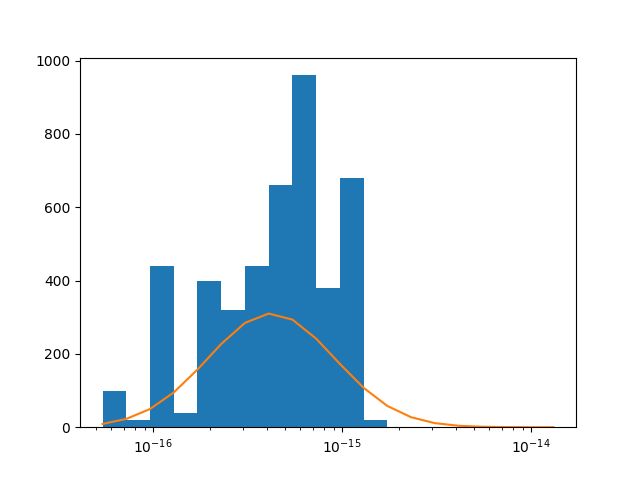

In [399]:
data = pd_all_amps.loc[pd_all_amps.dist==45000.0]
x = np.logspace(np.log10(data.amp_RW.min()), np.log10(data.amp_RW.max()*10), 20)
s1, _, c1 = lognorm.fit(data.amp_RW.values, floc=0)

Y = lognorm(s=s1, loc=0, scale=c1)
plt.figure()
#for type_mt, data_loc in data.groupby('depth'):
#    plt.hist(data_loc.amp_RW.values, bins=x)
plt.hist(data.amp_RW.values, bins=x)
plt.plot(x, x*Y.pdf(x)*600)
#plt.hist2d(data_loc.amp_RW.values, data_loc.az.values, bins=(x,data.az.unique()))
plt.xscale('log')

In [191]:
file_curve = '/projects/restricted/infrasound/data/infrasound/2023_Venus_inversion/GF_Dirac_1Hz_all_wfreq_Hot25.csv'
depths = [0, 50.]
pd_all_amps_store = pd.read_csv(file_curve, header=[0])
#pd_all_amps_store = pd_all_amps_store.loc[(pd_all_amps_store.depth>=depths[0]*1e3)&(pd_all_amps_store.depth<=depths[1]*1e3)]

In [374]:
from scipy import interpolate
model= 'Cold100'
unknown = 'pressure'
freq = 0.01
file = f'{dir_GF}GF_Dirac_1Hz_combined_wHot40_lognormal.csv'
TL_all_test = pd.read_csv(file, header=[0])
comp = 'v' if unknown in ['pressure', 'velocity'] else 'u'
TL_all_test = TL_all_test.loc[(TL_all_test.model == model)&(TL_all_test.comp == comp)&(TL_all_test.freq == freq)]
f_shape = interpolate.interp1d(TL_all_test.distance.values, TL_all_test['shape'].values, bounds_error=False, fill_value=(TL_all_test['shape'].values[0], TL_all_test['shape'].values[-1]))
f_scale = interpolate.interp1d(TL_all_test.distance.values, TL_all_test['scale'].values, bounds_error=False, fill_value=(TL_all_test['scale'].values[0], TL_all_test['scale'].values[-1]))

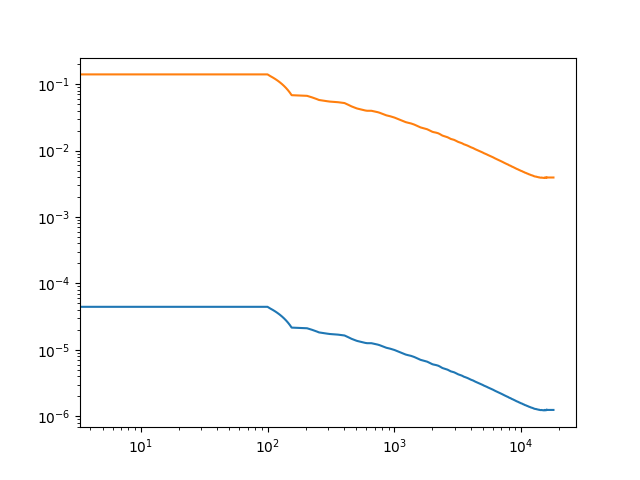

In [385]:
ratio, factor = 3154.933089894246, 1.1220184543019561e+18
#ratio = 1.
plt.figure()
plt.plot(TL_all_test.distance.values, TL_all_test['scale'].values)
plt.plot(TL_all_test.distance.values, ratio*pmt.magnitude_to_moment(6.)*f_scale(TL_all_test.distance.values)/factor)
plt.xscale('log')
plt.yscale('log')

In [156]:
from scipy import special

def lognorm_cdf(x, shape, loc=0.0, scale=1.0):
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)             # CDF = 0 for x <= loc
    m = x > loc
    z = np.log((x[m] - loc) / scale) / shape
    # Numerically stable form (avoid 1 - tiny):
    out[m] = 0.5 * special.erfc(-z / np.sqrt(2.0))
    return out

def piecewise_lognorm_cdf(x, tau, pi, p1, p2):
    s1, l1, c1 = p1
    s2, l2, c2 = p2
    x = np.asarray(x)
    F  = np.zeros_like(x, dtype=float)

    F1_tau = lognorm_cdf(tau, s1, loc=l1, scale=c1)
    F2_tau = lognorm_cdf(tau, s2, loc=l2, scale=c2)

    left = x <= tau
    #F[left]  = pi * lognorm.cdf(x[left], s1, loc=l1, scale=c1) / F1_tau
    F[left]  = pi * lognorm_cdf(x[left], s1, loc=l1, scale=c1) / F1_tau
    F[~left] = pi + (1.0 - pi) * (lognorm_cdf(x[~left], s2, loc=l2, scale=c2) - F2_tau) / (1.0 - F2_tau)
    return F

# Fit with a fixed tau
tau = 2e-15
test = pd_all_amps_store.loc[(pd_all_amps_store.dist==55000)&(pd_all_amps_store.amp_RW>1e-26)]
d = test.amp_RW.values
x = np.logspace(np.log10(d.min()), np.log10(d.max()), 100)
lo, hi = d[d <= tau], d[d > tau]
pi = lo.size / d.size

# Fit each side (usually fix loc=0 unless you truly need a shift)
s1, l1, c1 = lognorm.fit(lo, floc=0)
Y = lognorm(s=s1, loc=l1, scale=c1)
lognormal_distrib_1 = Y.pdf(x)
s2, l2, c2 = lognorm.fit(hi, floc=0)
Y = lognorm(s=s2, loc=l2, scale=c2)
lognormal_distrib_2 = Y.pdf(x)

# Total CDF and survival
F_total   = piecewise_lognorm_cdf(x, tau, pi, (s1,l1,c1), (s2,l2,c2))
cums      = 1.0 - F_total

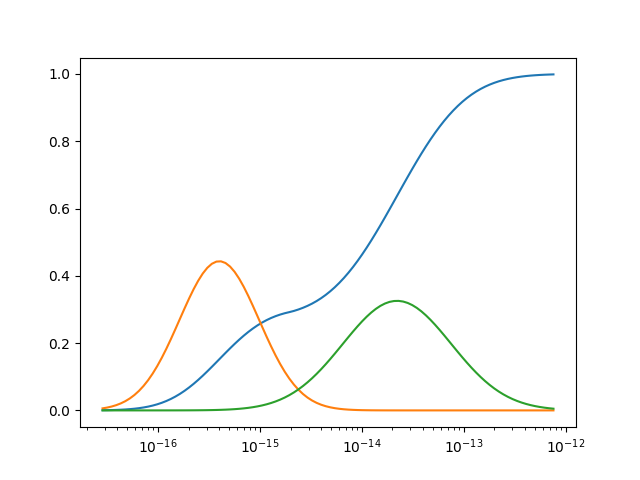

In [157]:
plt.figure()
plt.plot(x, F_total)
plt.plot(x, x*lognormal_distrib_1)
plt.plot(x, x*lognormal_distrib_2)
plt.xscale('log')

1.0670008574017555 0.0 3.769006159559349e-14


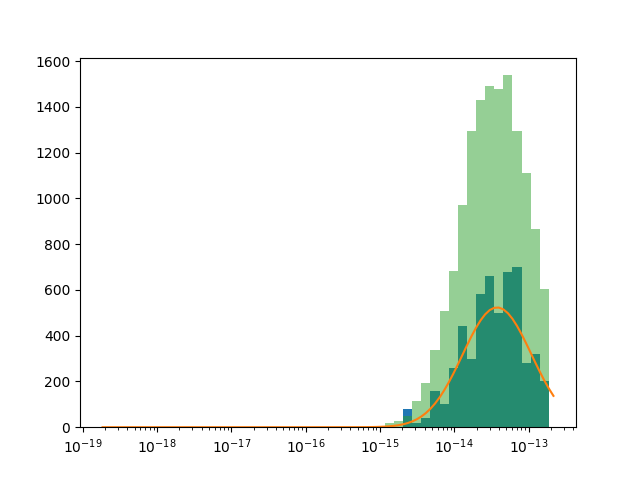

In [286]:
def get_pdf(data):
    shape, loc, scale = lognorm.fit(data, floc=0.)
    print(shape, loc, scale)
    Y = lognorm(s=shape, loc=loc, scale=scale)
    test_Y = Y.rvs(15000)
    lognormal_distrib_test = Y.pdf(x)
    return lognormal_distrib_test, test_Y

"""
pdf_manual = np.zeros_like(x, dtype=float)
m = x > loc
z = np.log((x[m] - loc) / scale) / shape
pdf_manual[m] = np.exp(-0.5*z*z) / ((x[m] - loc) * shape * np.sqrt(2*np.pi))
"""

ffs=np.unique(pd_all_amps_store[['fmin', 'fmax']], axis=0)
ifreq = 1
test = pd_all_amps_store.loc[(pd_all_amps_store.dist==55000)&(pd_all_amps_store.amp_RW>1e-26)&(pd_all_amps_store.fmin==ffs[ifreq,0])&(pd_all_amps_store.fmax==ffs[ifreq,1])]
#test = pd_all_amps_dist.copy()
data = test.amp_RW.values

plt.figure()

plt.hist(data, bins=x[::2], density=False)

#lognormal_distrib_test, test_Y = get_pdf(data[data>2e-15])
#plt.plot(x, 1400*x*lognormal_distrib_test)
#plt.hist(test_Y, bins=x[::2], density=False, alpha=0.5)

lognormal_distrib_test, test_Y = get_pdf(data)
plt.plot(x, 1400*x*lognormal_distrib_test)
plt.hist(test_Y, bins=x[::2], density=False, alpha=0.5)


plt.xscale('log')

Text(0.5, 0, 'Distance (km)')

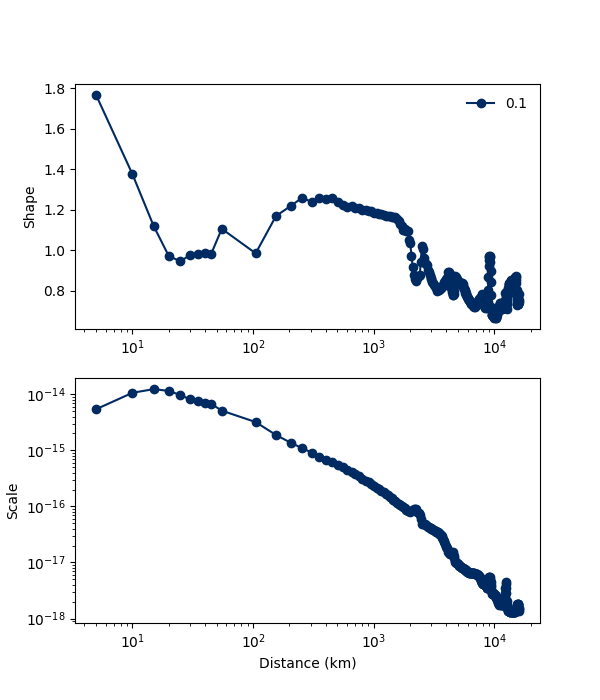

In [246]:
import matplotlib.cm as cm
from matplotlib import gridspec

cmap = cm.get_cmap("cividis")
colors = [cmap(x) for x in np.linspace(0.05, 0.95, 3)]

x = np.logspace(np.log10(test.amp_RW.min()), np.log10(test.amp_RW.max()), 100)

fig = plt.figure(figsize=(6,7))
gs  = gridspec.GridSpec(nrows=2, ncols=1, figure=fig, wspace=0.0)
    
ax  = fig.add_subplot(gs[0, 0])
ax2  = fig.add_subplot(gs[1, 0], sharex=ax)
iff = -1
for fmax, pd_gamma_store in pd_gamma.groupby('freq'):
    iff += 1
    first_pass = True
        
    label_fmt = dict()
    if first_pass:
        label_fmt = dict(label=fmax)
    ax.plot(pd_gamma_store.dist/1e3, pd_gamma_store.s1, color=colors[iff], marker='o', **label_fmt)
    #ax.plot(pd_gamma_store.dist/1e3, pd_gamma_store.l1, color=colors[iff], marker='o', **label_fmt)
    ax2.plot(pd_gamma_store.dist/1e3, pd_gamma_store.c1, color=colors[iff], marker='o', **label_fmt)
    #for idist, pd_gamma_dist in pd_gamma_store.iterrows():
    #    pdf_fitted = gamma.pdf(x, pd_gamma_dist['shape'], loc=pd_gamma_dist['loc'], scale=pd_gamma_dist['scale'])
    #    plt.scatter(np.zeros_like(pdf_fitted) + pd_gamma_dist.dist, pdf_fitted, c=pdf_fitted)
    first_pass = False
        
ax.legend(frameon=False)
ax.set_ylabel('Shape')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylabel('Scale')
ax2.set_xlabel('Distance (km)')

In [5]:
pd_all_amps = pd.read_csv('/projects/restricted/infrasound/data/infrasound/2023_Venus_inversion/GF_Dirac_1Hz_all_wfreq_Cold100_u.csv', header=[0])

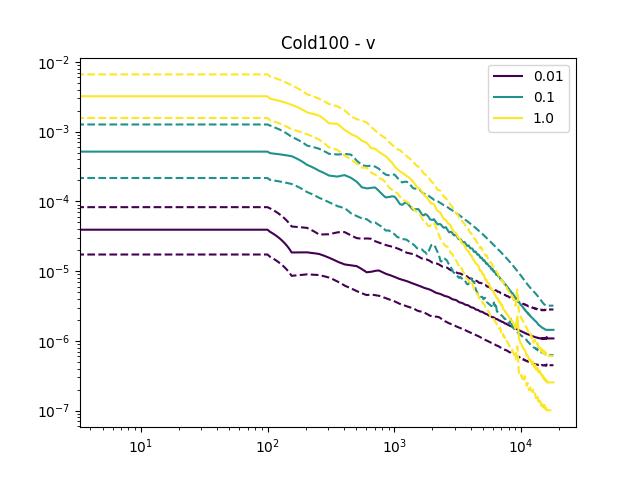

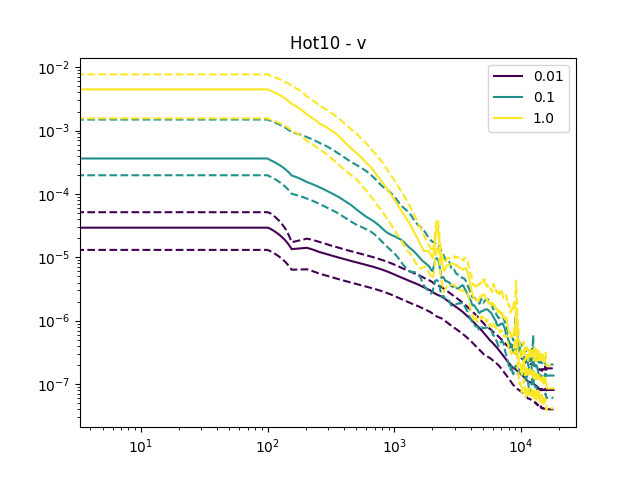

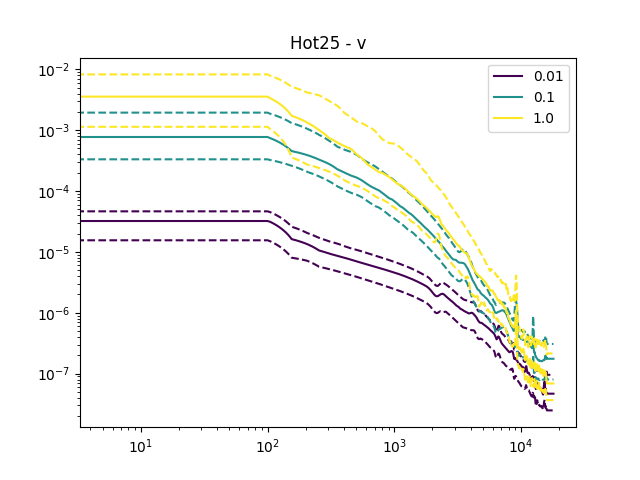

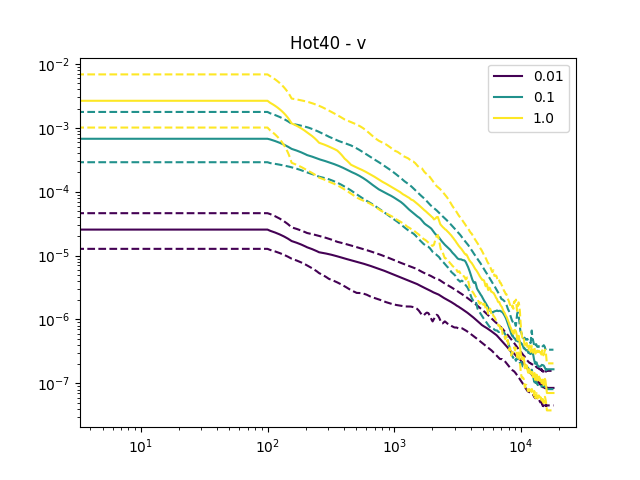

In [10]:
cmap = plt.get_cmap('viridis')  # or 'plasma', 'inferno', 'coolwarm', etc.
n = len(TL_all.freq.unique())
colors = [cmap(i / (n - 1)) for i in range(n)]

for (model, comp), TL_loc in TL_all.groupby(['model', 'comp']):
    plt.figure()
    plt.title(f'{model} - {comp}')
    ii = -1
    for ff, TL in TL_loc.groupby('freq'):
        ii += 1
        TL = TL.sort_values(by=['distance'])
        plt.plot(TL.distance, TL.amp_median, label=ff, color=colors[ii])
        plt.plot(TL.distance, TL.amp_qmin, ls='--', color=colors[ii])
        plt.plot(TL.distance, TL.amp_qmax, ls='--', color=colors[ii])
    plt.legend()
    plt.xscale('log')
    plt.yscale('log')

In [140]:
reload(pm)
file_curve = f'{dir_GF}GF_Dirac_1Hz_combined.csv'
alt = 50.
TL_new, TL_new_qmin, TL_new_qmax = pm.get_TL_curves_precomputed(file_curve, rho0=f_rho(0.), rhob=f_rho(alt), cb=f_c(alt), unknown='pressure', model='Cold100')

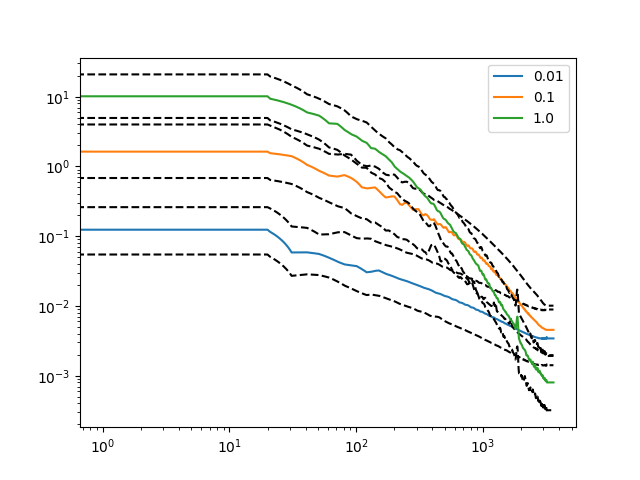

In [141]:
dists = np.arange(0, 18000., 5.)
m0 = 6. 

plt.figure()
for freq, TL in TL_new.items():
    plt.plot(TL(dists, m0), label=freq)
    plt.plot(TL_new_qmin[freq](dists, m0), color='black', ls='--')
    plt.plot(TL_new_qmax[freq](dists, m0), color='black', ls='--')
plt.yscale('log')
plt.xscale('log')
plt.legend()

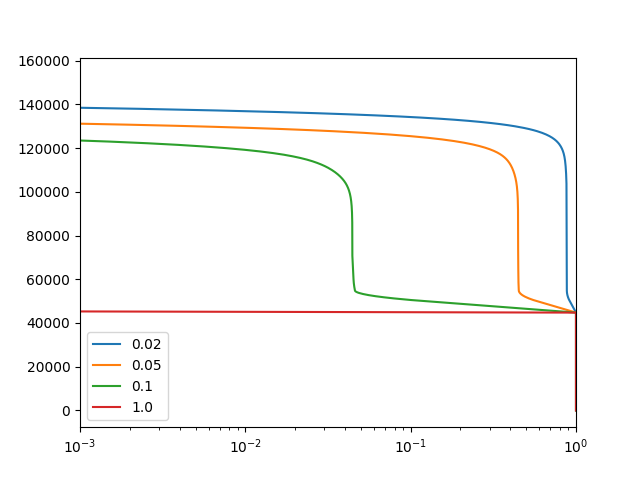

In [136]:
dalt = altitude[1] - altitude[0]
plt.figure()
for ifreq in range(alpha.shape[0]):
    atten = np.exp(-np.cumsum(alpha[ifreq, :]) * dalt/1e3)
    plt.plot(atten, altitude, label=frequency[ifreq])
plt.xscale('log')
plt.xlim([1e-3, 1])
plt.legend()